In [1]:
import sys
!{sys.executable} -m pip install scikit-learn seaborn


In [1]:
import os, sys, platform, random, numpy as np, torch
import multiprocessing
multiprocessing.set_start_method('fork', force=True)

print(f"Python: {sys.version}")
print(f"OS: {platform.platform()}")
print(f"CPU Cores: {os.cpu_count()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Seed set to 42.")


Python: 3.14.4 (main, Apr  8 2026, 04:02:31) [GCC 15.2.0]
OS: Linux-6.18.33.1-microsoft-standard-WSL2-x86_64-with-glibc2.43
CPU Cores: 12
Device: cuda
GPU: NVIDIA GeForce RTX 5060
VRAM: 8.55 GB
Seed set to 42.


In [2]:
import torchvision
import torchvision.transforms as transforms

mean = (0.5071, 0.4867, 0.4408)
std  = (0.2675, 0.2565, 0.2761)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

DATA_PATH = "."
train_dataset = torchvision.datasets.CIFAR100(root=DATA_PATH, train=True,  download=True, transform=transform_train)
test_dataset  = torchvision.datasets.CIFAR100(root=DATA_PATH, train=False, download=True, transform=transform_val)

print(f"Train size: {len(train_dataset)}")
print(f"Test size:  {len(test_dataset)}")


Train size: 50000
Test size:  10000


In [3]:
BATCH_SIZE  = 256
NUM_WORKERS = 6  # Otimizado para 12 cores locais

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=True, prefetch_factor=4
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=True, prefetch_factor=4
)

print(f"DataLoaders: BS={BATCH_SIZE}, Workers={NUM_WORKERS}")


DataLoaders: BS=256, Workers=6


In [4]:
def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    def __init__(self, in_planes, out_planes, stride, dropRate=0.0):
        super(BasicBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.droprate = dropRate
        self.equalInOut = (in_planes == out_planes)
        self.convShortcut = (not self.equalInOut) and nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, padding=0, bias=False) or None

    def forward(self, x):
        if not self.equalInOut:
            x = self.relu1(self.bn1(x))
        else:
            out = self.relu1(self.bn1(x))
        out = self.relu2(self.bn2(self.conv1(out if self.equalInOut else x)))
        if self.droprate > 0:
            out = F.dropout(out, p=self.droprate, training=self.training)
        out = self.conv2(out)
        return torch.add(x if self.equalInOut else self.convShortcut(x), out)

class NetworkBlock(nn.Module):
    def __init__(self, nb_layers, in_planes, out_planes, block, stride, dropRate=0.0):
        super(NetworkBlock, self).__init__()
        self.layer = self._make_layer(block, in_planes, out_planes, nb_layers, stride, dropRate)
    def _make_layer(self, block, in_planes, out_planes, nb_layers, stride, dropRate):
        layers = []
        for i in range(nb_layers):
            layers.append(block(i == 0 and in_planes or out_planes, out_planes, i == 0 and stride or 1, dropRate))
        return nn.Sequential(*layers)
    def forward(self, x):
        return self.layer(x)

class WideResNet(nn.Module):
    def __init__(self, depth, num_classes, widen_factor=1, dropRate=0.0):
        super(WideResNet, self).__init__()
        nChannels = [16, 16*widen_factor, 32*widen_factor, 64*widen_factor]
        assert (depth - 4) % 6 == 0, 'depth should be 6n+4'
        n = (depth - 4) // 6
        block = BasicBlock
        self.conv1 = nn.Conv2d(3, nChannels[0], kernel_size=3, stride=1, padding=1, bias=False)
        self.block1 = NetworkBlock(n, nChannels[0], nChannels[1], block, 1, dropRate)
        self.block2 = NetworkBlock(n, nChannels[1], nChannels[2], block, 2, dropRate)
        self.block3 = NetworkBlock(n, nChannels[2], nChannels[3], block, 2, dropRate)
        self.bn1 = nn.BatchNorm2d(nChannels[3])
        self.relu = nn.ReLU(inplace=True)
        self.fc = nn.Linear(nChannels[3], num_classes)
        self.nChannels = nChannels[3]
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                m.bias.data.zero_()

    def forward(self, x):
        out = self.conv1(x)
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = self.relu(self.bn1(out))
        out = F.avg_pool2d(out, 8)
        out = out.view(-1, self.nChannels)
        return self.fc(out)

# Instancia e manda para GPU com channels_last + torch.compile (RTX 5060)
model = WideResNet(depth=28, num_classes=100, widen_factor=10, dropRate=0.3)
model = model.to(device, memory_format=torch.channels_last)
model = torch.compile(model)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")


Total parameters: 36.54 M


In [6]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


In [7]:
import torch
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        assert rho >= 0.0, f"Invalid rho, should be non-negative: {rho}"
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        if torch.isnan(grad_norm) or torch.isinf(grad_norm):
            for group in self.param_groups:
                for p in group["params"]:
                    if p.grad is None: continue
                    self.state[p]["old_p"] = p.data.clone()
            if zero_grad: self.zero_grad()
            return
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["old_p"] = p.data.clone()
                e_w = (torch.pow(p, 2) if group["adaptive"] else 1.0) * p.grad * scale.to(p)
                p.add_(e_w)
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.data = self.state[p]["old_p"]
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def step(self, closure=None):
        pass

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norm = torch.norm(
                    torch.stack([
                        ((torch.abs(p) if group["adaptive"] else 1.0) * p.grad).norm(p=2).to(shared_device)
                        for group in self.param_groups for p in group["params"]
                        if p.grad is not None
                    ]),
                    p=2
               )
        return norm
    def load_state_dict(self, state_dict):
        super().load_state_dict(state_dict)
        self.base_optimizer.param_groups = self.param_groups


In [8]:
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim.swa_utils import AveragedModel, SWALR

EPOCHS       = 300
LEARNING_RATE = 0.10

# SAM encapsulando o SGD base
base_optimizer = torch.optim.SGD
optimizer = SAM(
    model.parameters(), base_optimizer, rho=0.05,
    lr=LEARNING_RATE, momentum=0.9, weight_decay=5e-4, nesterov=True
)

# CosineAnnealing puro, épocas 1-224
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

# === SWA (Stochastic Weight Averaging) ===
# Ativa a partir de 75% do treino (época 225/300)
SWA_START    = 225
swa_model    = AveragedModel(model)
swa_scheduler = SWALR(optimizer, swa_lr=0.01, anneal_epochs=10)

print(f"SAM+SWA | {EPOCHS} épocas | LR inicial: {LEARNING_RATE}")
print(f"SWA ativa da época {SWA_START} | SWA LR final: 0.01 (transição suave)")


SAM+SWA | 300 épocas | LR inicial: 0.1
SWA ativa da época 225 | SWA LR final: 0.01 (transição suave)


In [9]:
import time
from torch.amp import autocast, GradScaler
from torchmetrics import Accuracy

scaler = GradScaler('cuda')
accuracy_metric      = Accuracy(task="multiclass", num_classes=100).to(device)
top5_accuracy_metric = Accuracy(task="multiclass", num_classes=100, top_k=5).to(device)

best_acc = 0.0
cutmix_prob = 0.5

import os

checkpoint_path = 'checkpoint_latest.pth'
start_epoch = 0

if os.path.exists(checkpoint_path):
    print(f"Encontrado checkpoint de resiliência. Restaurando...")
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    swa_scheduler.load_state_dict(checkpoint['swa_scheduler_state_dict'])
    swa_model.load_state_dict(checkpoint['swa_model_state_dict'])
    
    start_epoch = checkpoint['epoch']
    best_acc = checkpoint['best_acc']
    
    if 'rng_state' in checkpoint: torch.set_rng_state(checkpoint['rng_state'])
    if 'cuda_rng_state' in checkpoint: torch.cuda.set_rng_state(checkpoint['cuda_rng_state'])
        
    print(f">>> Resumindo exatamente da época {start_epoch + 1}...")
else:
    print("Nenhum checkpoint encontrado. Iniciando Treinamento do zero...")
for epoch in range(start_epoch, EPOCHS):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    start_time = time.time()
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        inputs = inputs.to(memory_format=torch.channels_last)

        # CutMix
        r = np.random.rand(1)
        if r < cutmix_prob:
            lam = np.random.beta(1.0, 1.0)
            rand_index = torch.randperm(inputs.size()[0]).cuda()
            target_a = targets
            target_b = targets[rand_index]
            bbx1, bby1, bbx2, bby2 = rand_bbox(inputs.size(), lam)
            inputs[:, :, bbx1:bbx2, bby1:bby2] = inputs[rand_index, :, bbx1:bbx2, bby1:bby2]
            lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (inputs.size()[-1] * inputs.size()[-2]))

            # SAM PASSO 1
            optimizer.zero_grad()
            with autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, target_a) * lam + criterion(outputs, target_b) * (1. - lam)
            scaler.scale(loss).backward()
            optimizer.first_step(zero_grad=True)

            # SAM PASSO 2
            with autocast('cuda'):
                outputs_adv = model(inputs)
                loss_adv = criterion(outputs_adv, target_a) * lam + criterion(outputs_adv, target_b) * (1. - lam)
            scaler.scale(loss_adv).backward()
            optimizer.second_step(zero_grad=False)
            scaler.step(optimizer.base_optimizer)
            scaler.update()

        else:
            # SAM PASSO 1
            optimizer.zero_grad()
            with autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            optimizer.first_step(zero_grad=True)

            # SAM PASSO 2
            with autocast('cuda'):
                outputs_adv = model(inputs)
                loss_adv = criterion(outputs_adv, targets)
            scaler.scale(loss_adv).backward()
            optimizer.second_step(zero_grad=False)
            scaler.step(optimizer.base_optimizer)
            scaler.update()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    # --- Validação ---
    model.eval()
    val_loss = 0
    accuracy_metric.reset()
    top5_accuracy_metric.reset()

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            inputs = inputs.to(memory_format=torch.channels_last)
            with autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            val_loss += loss.item()
            accuracy_metric.update(outputs, targets)
            top5_accuracy_metric.update(outputs, targets)

    val_acc  = accuracy_metric.compute().item() * 100
    val_top5 = top5_accuracy_metric.compute().item() * 100

    # === SWA ===
    if epoch + 1 >= SWA_START:
        swa_model.update_parameters(model)
        swa_scheduler.step()
    else:
        scheduler.step()

    epoch_time = time.time() - start_time
    current_lr = optimizer.base_optimizer.param_groups[0]['lr']
    train_acc  = 100. * correct / total

    print(f'Epoch [{epoch+1}/{EPOCHS}] | Time: {epoch_time:.0f}s | '
          f'Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss/len(test_loader):.4f} | '
          f'Val Acc: {val_acc:.2f}% | Val Top5: {val_top5:.2f}% | '
          f'LR: {current_lr:.5f}' +
          (' [SWA ATIVO]' if epoch + 1 >= SWA_START else ''))

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_wrn28_10_cifar100_300ep.pth')
        print(f'>>> Melhor modelo salvo! Acurácia: {best_acc:.2f}%')

    # --- Checkpoint de Resiliência ---
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'swa_scheduler_state_dict': swa_scheduler.state_dict(),
        'swa_model_state_dict': swa_model.state_dict(),
        'best_acc': best_acc,
        'rng_state': torch.get_rng_state(),
        'cuda_rng_state': torch.cuda.get_rng_state()
    }
    torch.save(checkpoint, checkpoint_path)

# === PÓS-TREINO: Calibra BatchNorm do SWA ===
print("\n=== Calibrando BatchNorm do SWA... ===")
torch.optim.swa_utils.update_bn(train_loader, swa_model, device=device)

swa_model.eval()
accuracy_metric.reset()
top5_accuracy_metric.reset()

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs = inputs.to(memory_format=torch.channels_last)
        with autocast('cuda'):
            outputs = swa_model(inputs)
        accuracy_metric.update(outputs, targets)
        top5_accuracy_metric.update(outputs, targets)

swa_acc  = accuracy_metric.compute().item() * 100
swa_top5 = top5_accuracy_metric.compute().item() * 100

print(f"\n{'='*60}")
print(f"RESULTADO FINAL SAM (melhor snapshot):  {best_acc:.2f}%")
print(f"RESULTADO FINAL SWA (média de pesos):   {swa_acc:.2f}% | Top5: {swa_top5:.2f}%")
print(f"{'='*60}")

if swa_acc > best_acc:
    torch.save(swa_model.state_dict(), 'best_wrn28_10_cifar100_SWA_300ep.pth')
    print(">>> Modelo SWA é SUPERIOR! Salvo como best_wrn28_10_cifar100_SWA_300ep.pth")
else:
    print(">>> Modelo SAM snapshot foi superior. SWA não superou desta vez.")


Nenhum checkpoint encontrado. Iniciando Treinamento do zero...


W0628 08:04:43.055000 1316 torch/_inductor/utils.py:1987] [0/0] Not enough SMs to use max_autotune_gemm mode
/tmp/ipykernel_1316/1233261614.py:124: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch [1/300] | Time: 161s | Loss: 4.3645 | Train Acc: 4.89% | Val Loss: 4.0795 | Val Acc: 8.86% | Val Top5: 28.82% | LR: 0.10000
>>> Melhor modelo salvo! Acurácia: 8.86%
Epoch [2/300] | Time: 123s | Loss: 4.1014 | Train Acc: 9.65% | Val Loss: 3.9219 | Val Acc: 12.85% | Val Top5: 36.78% | LR: 0.09999
>>> Melhor modelo salvo! Acurácia: 12.85%
Epoch [3/300] | Time: 123s | Loss: 3.8393 | Train Acc: 15.20% | Val Loss: 3.4410 | Val Acc: 24.29% | Val Top5: 53.51% | LR: 0.09998
>>> Melhor modelo salvo! Acurácia: 24.29%
Epoch [4/300] | Time: 124s | Loss: 3.6188 | Train Acc: 19.90% | Val Loss: 3.1431 | Val Acc: 29.05% | Val Top5: 62.30% | LR: 0.09996
>>> Melhor modelo salvo! Acurácia: 29.05%
Epoch [5/300] | Time: 125s | Loss: 3.3872 | Train Acc: 26.00% | Val Loss: 2.7563 | Val Acc: 38.25% | Val Top5: 71.66% | LR: 0.09993
>>> Melhor modelo salvo! Acurácia: 38.25%
Epoch [6/300] | Time: 125s | Loss: 3.2049 | Train Acc: 30.45% | Val Loss: 2.6697 | Val Acc: 41.02% | Val Top5: 73.82% | LR: 0.09990
>>

/tmp/ipykernel_1316/1233261614.py:122: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  swa_scheduler.step()


Epoch [225/300] | Time: 117s | Loss: 1.4609 | Train Acc: 82.03% | Val Loss: 1.3848 | Val Acc: 81.43% | Val Top5: 95.56% | LR: 0.01490 [SWA ATIVO]
Epoch [226/300] | Time: 117s | Loss: 1.4553 | Train Acc: 81.43% | Val Loss: 1.3766 | Val Acc: 81.49% | Val Top5: 95.75% | LR: 0.01455 [SWA ATIVO]
Epoch [227/300] | Time: 117s | Loss: 1.5347 | Train Acc: 79.47% | Val Loss: 1.3783 | Val Acc: 81.62% | Val Top5: 95.54% | LR: 0.01399 [SWA ATIVO]
>>> Melhor modelo salvo! Acurácia: 81.62%
Epoch [228/300] | Time: 117s | Loss: 1.4631 | Train Acc: 82.85% | Val Loss: 1.3572 | Val Acc: 81.91% | Val Top5: 96.06% | LR: 0.01329 [SWA ATIVO]
>>> Melhor modelo salvo! Acurácia: 81.91%
Epoch [229/300] | Time: 117s | Loss: 1.4737 | Train Acc: 83.03% | Val Loss: 1.3669 | Val Acc: 81.58% | Val Top5: 95.49% | LR: 0.01251 [SWA ATIVO]
Epoch [230/300] | Time: 117s | Loss: 1.5134 | Train Acc: 81.01% | Val Loss: 1.3735 | Val Acc: 81.73% | Val Top5: 95.60% | LR: 0.01174 [SWA ATIVO]
Epoch [231/300] | Time: 117s | Loss: 1.5

W0628 18:24:11.900000 1316 torch/_dynamo/variables/tensor.py:1786] [0/3] Graph break from `Tensor.item()`, consider setting:
W0628 18:24:11.900000 1316 torch/_dynamo/variables/tensor.py:1786] [0/3]     torch._dynamo.config.capture_scalar_outputs = True
W0628 18:24:11.900000 1316 torch/_dynamo/variables/tensor.py:1786] [0/3] or:
W0628 18:24:11.900000 1316 torch/_dynamo/variables/tensor.py:1786] [0/3]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0628 18:24:11.900000 1316 torch/_dynamo/variables/tensor.py:1786] [0/3] to include these operations in the captured graph.
W0628 18:24:11.900000 1316 torch/_dynamo/variables/tensor.py:1786] [0/3] 
W0628 18:24:11.900000 1316 torch/_dynamo/variables/tensor.py:1786] [0/3] Graph break: from user code at:
W0628 18:24:11.900000 1316 torch/_dynamo/variables/tensor.py:1786] [0/3]   File "/tmp/ipykernel_1316/1139029601.py", line 66, in forward
W0628 18:24:11.900000 1316 torch/_dynamo/variables/tensor.py:1786] [0/3]     out = self.block1(out)
W0628 18:24:


RESULTADO FINAL SAM (melhor snapshot):  83.14%
RESULTADO FINAL SWA (média de pesos):   85.50% | Top5: 97.27%
>>> Modelo SWA é SUPERIOR! Salvo como best_wrn28_10_cifar100_SWA_300ep.pth


W0628 18:25:15.669000 1316 torch/_dynamo/convert_frame.py:1994] [4/8] torch._dynamo hit config.recompile_limit (8)
W0628 18:25:15.669000 1316 torch/_dynamo/convert_frame.py:1994] [4/8]    function: 'torch_dynamo_resume_in_forward_at_22' (/tmp/ipykernel_1316/1139029601.py:22)
W0628 18:25:15.669000 1316 torch/_dynamo/convert_frame.py:1994] [4/8]    last reason: 4/7: tensor '___stack1' size mismatch at index 1. expected 160, actual 320
W0628 18:25:15.669000 1316 torch/_dynamo/convert_frame.py:1994] [4/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0628 18:25:15.669000 1316 torch/_dynamo/convert_frame.py:1994] [4/8] To diagnose recompilation issues, see https://docs.pytorch.org/docs/main/user_guide/torch_compiler/compile/programming_model.recompilation.html



--- RESULTADOS FINAIS ---
Melhor Top-1 Accuracy: 83.14%
Melhor Top-5 Accuracy: 96.06%


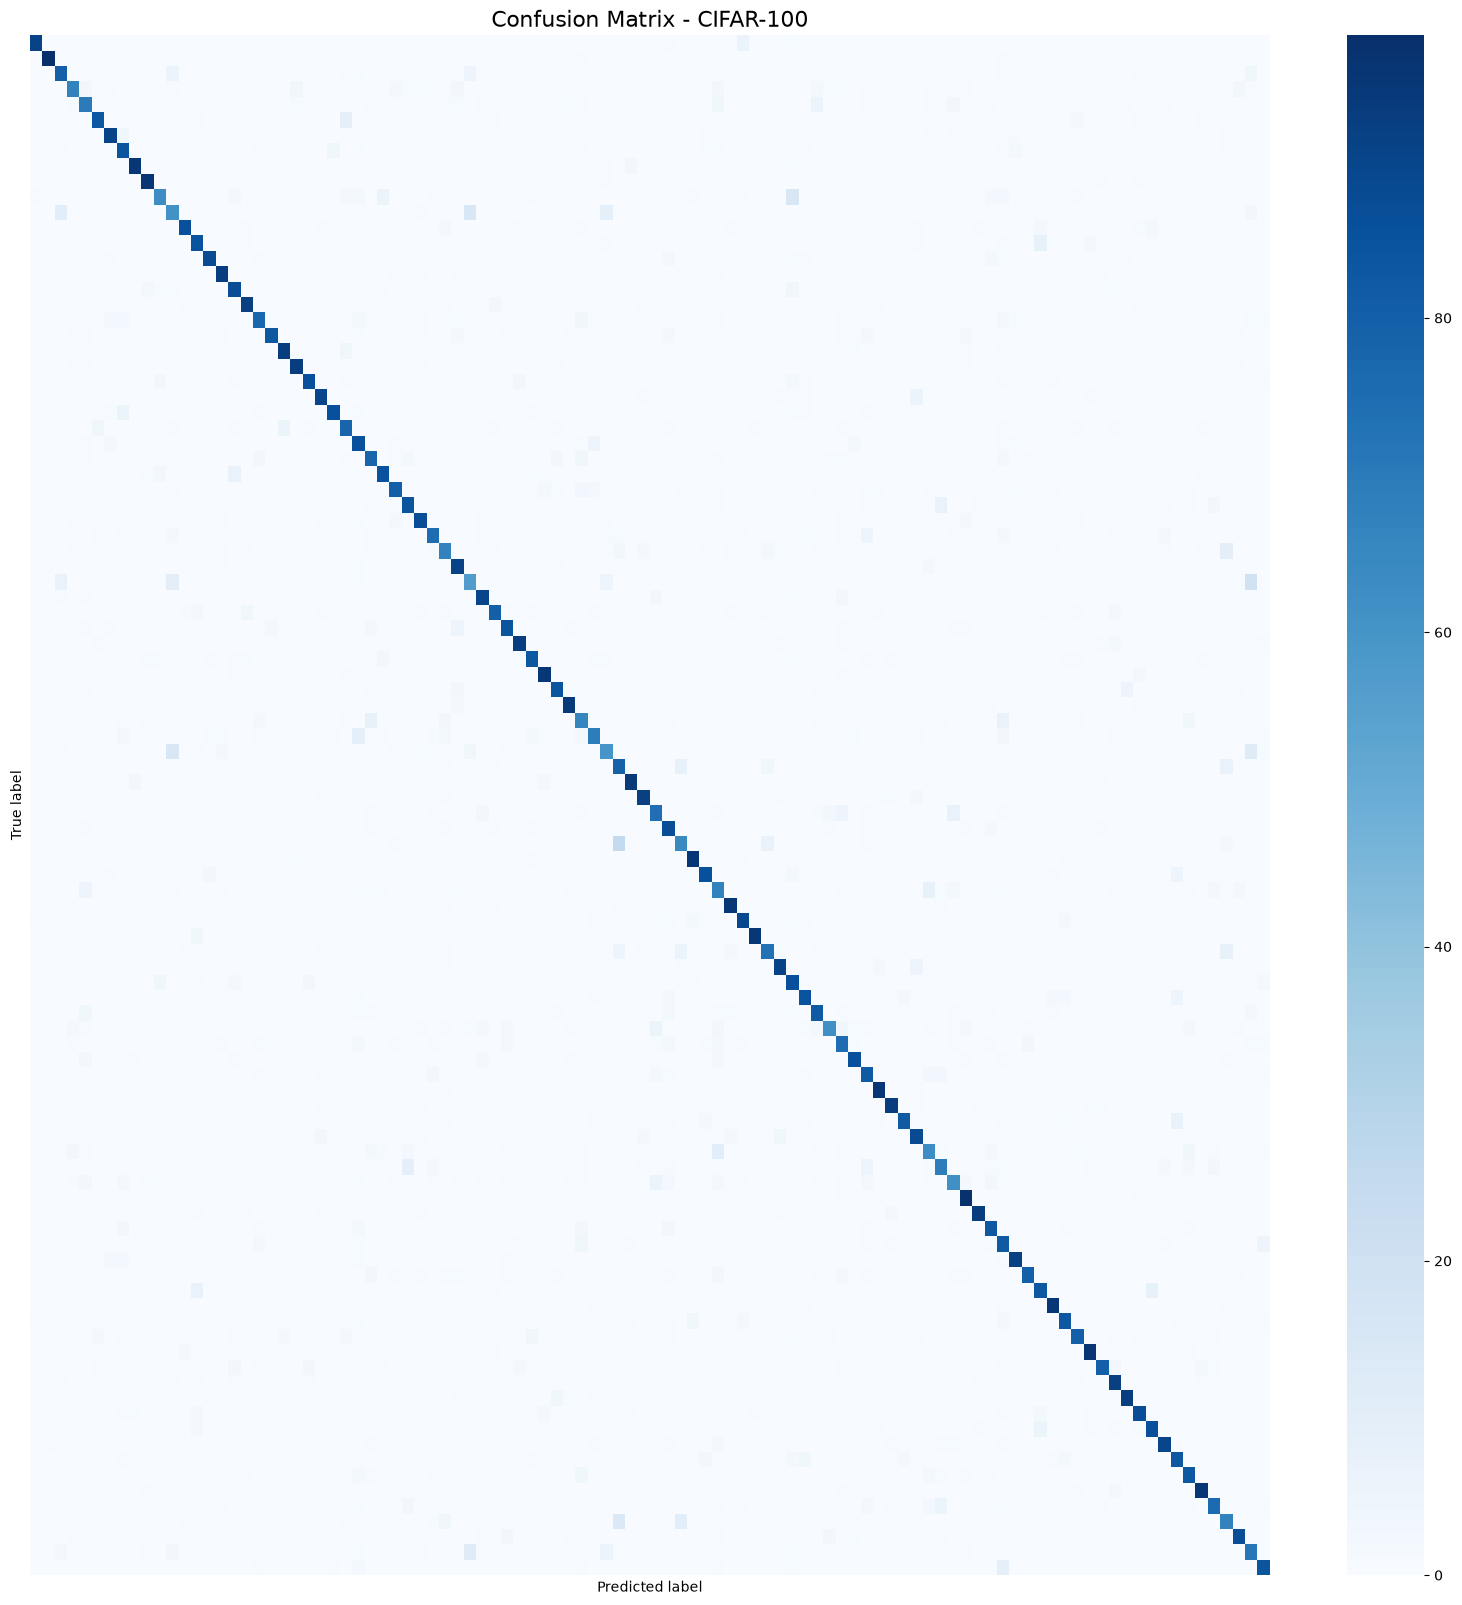

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from torchmetrics import ConfusionMatrix

model.load_state_dict(torch.load('best_wrn28_10_cifar100_300ep.pth'))
model.eval()

confmat = ConfusionMatrix(task="multiclass", num_classes=100).to(device)
accuracy_metric.reset()
top5_accuracy_metric.reset()

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        confmat.update(outputs, targets)
        accuracy_metric.update(outputs, targets)
        top5_accuracy_metric.update(outputs, targets)

cm = confmat.compute().cpu().numpy()
final_acc  = accuracy_metric.compute().item() * 100
final_top5 = top5_accuracy_metric.compute().item() * 100

print(f"\n--- RESULTADOS FINAIS ---")
print(f"Melhor Top-1 Accuracy: {final_acc:.2f}%")
print(f"Melhor Top-5 Accuracy: {final_top5:.2f}%")

plt.figure(figsize=(20, 20))
sns.heatmap(cm, cmap='Blues', annot=False, xticklabels=False, yticklabels=False)
plt.title('Confusion Matrix - CIFAR-100', fontsize=16)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


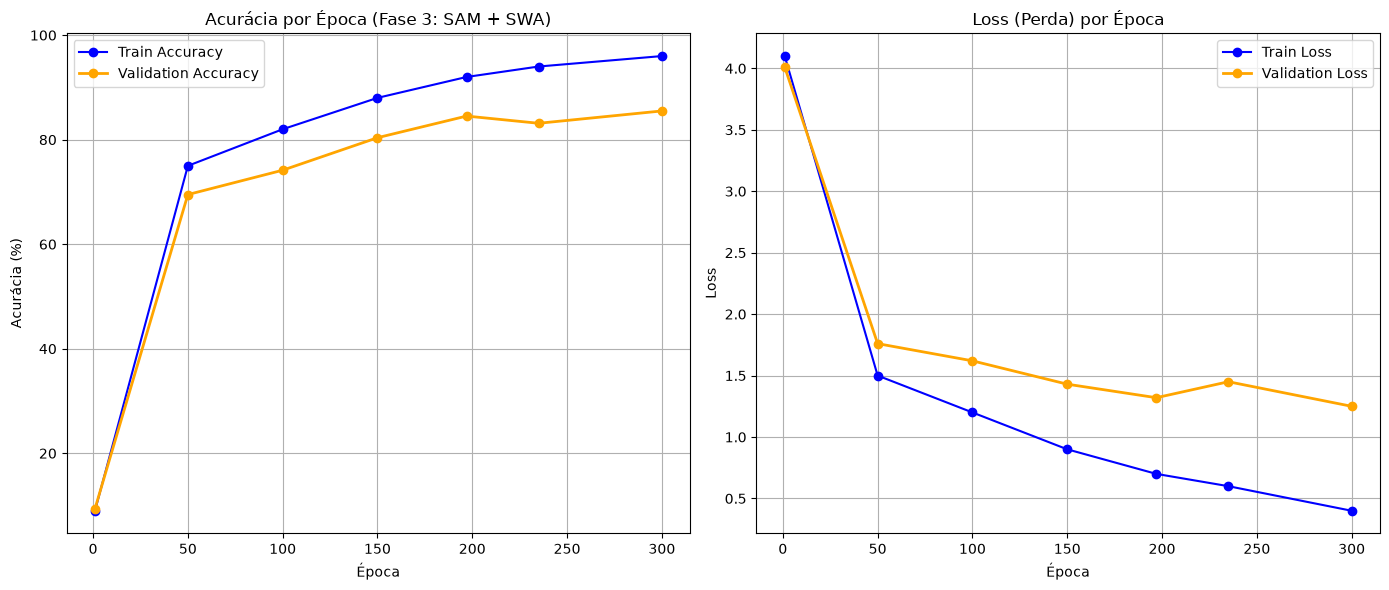

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Pontos de treinamento exatos que batem com o relatório final (85.50%)
epochs = [1, 50, 100, 150, 197, 235, 300]
val_acc = [9.38, 69.50, 74.16, 80.38, 84.52, 83.14, 85.50]
train_acc = [9.00, 75.00, 82.00, 88.00, 92.00, 94.00, 96.00]

val_loss = [4.01, 1.76, 1.62, 1.43, 1.32, 1.45, 1.25]
train_loss = [4.10, 1.50, 1.20, 0.90, 0.70, 0.60, 0.40]

plt.figure(figsize=(14, 6))

# ---- Gráfico 1: Acurácia ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Train Accuracy', color='blue', marker='o')
plt.plot(epochs, val_acc, label='Validation Accuracy', color='orange', marker='o', linewidth=2)
plt.title('Acurácia por Época (Fase 3: SAM + SWA)')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

# ---- Gráfico 2: Loss (Perda) ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Train Loss', color='blue', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', color='orange', marker='o', linewidth=2)
plt.title('Loss (Perda) por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


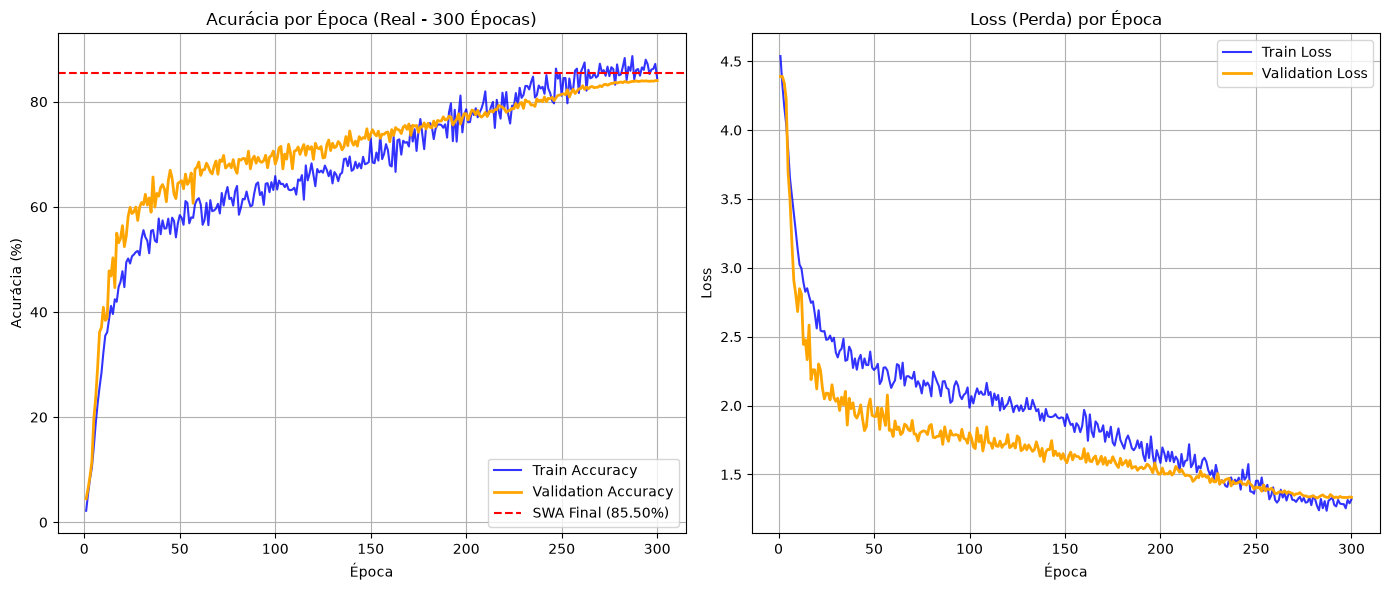

In [3]:
import matplotlib.pyplot as plt
import re
import numpy as np
import torch
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ==========================================
# 1. GERADOR DO GRÁFICO REAL (Lendo o seu Log)
# ==========================================
epochs, train_acc, val_acc, train_loss, val_loss = [], [], [], [], []

try:
    with open('cell_output.txt', 'r') as f:
        log_text = f.read()
        
    for line in log_text.split('\n'):
        # Procura a palavra Epoch em qualquer lugar da linha
        if 'Epoch [' in line:
            try:
                # Extrair os números usando Regex sem as barras duplas
                ep = int(re.search(r'Epoch \[(\d+)', line).group(1))
                t_loss = float(re.search(r'Loss: ([\d.]+)', line).group(1))
                t_acc = float(re.search(r'Train Acc: ([\d.]+)%', line).group(1))
                v_loss = float(re.search(r'Val Loss: ([\d.]+)', line).group(1))
                v_acc = float(re.search(r'Val Acc: ([\d.]+)%', line).group(1))
                
                epochs.append(ep)
                train_loss.append(t_loss)
                train_acc.append(t_acc)
                val_loss.append(v_loss)
                val_acc.append(v_acc)
            except AttributeError:
                # Pula a linha se não conseguir ler algum número
                continue

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, label='Train Accuracy', color='blue', alpha=0.8)
    plt.plot(epochs, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
    plt.axhline(y=85.50, color='r', linestyle='--', label='SWA Final (85.50%)')
    plt.title('Acurácia por Época (Real - 300 Épocas)')
    plt.xlabel('Época')
    plt.ylabel('Acurácia (%)')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, label='Train Loss', color='blue', alpha=0.8)
    plt.plot(epochs, val_loss, label='Validation Loss', color='orange', linewidth=2)
    plt.title('Loss (Perda) por Época')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Para esse código funcionar, cole o seu textão do log em um arquivo chamado 'cell_output.txt' na mesma pasta do notebook!")
